In [1]:
# sage -n jupyter --no-browser

import os, sys
from pathlib import Path

print("Working directory:", os.getcwd())
print("Kernel executable:", sys.executable)

if 'sage' in sys.executable.lower():
  target = Path("/mnt/d/Projects/m2-bezout/internship/src/notebooks/")
  os.chdir(target)
  print("Changed working directory to:", os.getcwd())

from typing import TYPE_CHECKING
if TYPE_CHECKING:
    from type_checking import *


import importlib

from utils import latex_print

# import monte_carlo
# importlib.reload(monte_carlo)
# from monte_carlo import sample_from_empirical, plot_distribution, pmf_to_particles, MeanOneGenerator, wasserstein

Working directory: /home/stages/chau/projects/m2-bezout/internship/src/local/notebooks
Kernel executable: /home/stages/chau/miniforge3/bin/python


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from math import isfinite

In [3]:
u, v = var("u v")
x = var("x")
alpha = var("alpha")

g(x) = (u+v)*x^alpha + u*(1-x)^alpha

x_star = (1+(1+v/u)^(1/(alpha-1)))^(-1)

g_x_star = g(x_star).full_simplify()

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (3040898899.py, line 5)

In [53]:
latex_print(g_x_star)

<IPython.core.display.Math object>

In [71]:
u_val = 0.8
v_val = 0

alpha_val = 2*(u_val + v_val) - 1

g_x_star_num = g_x_star.subs(u=u_val, v=v_val, alpha=alpha_val).n()
g_x_star_num

1.05560632861832

Grid points with g(x*) > 1: 875/32400 (2.70%)
Grid points in region 2u+v>1: 24390/32400 (75.28%)
Points with g(x*)>1 inside 2u+v>1: 875


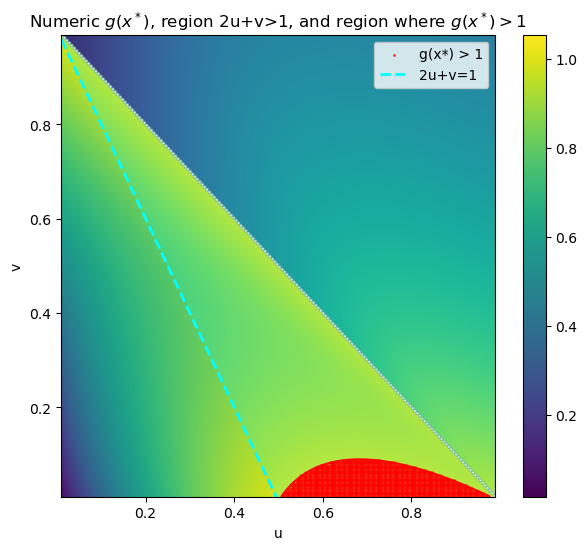

In [ ]:
# ranges (avoid u=0 and alpha close to 1 which makes x_star ill-defined)
u_vals = np.linspace(0.01, 0.99, 180)
v_vals = np.linspace(0.01, 0.99, 180)

G = np.full((len(v_vals), len(u_vals)), np.nan)

for i, v_val in enumerate(v_vals):
    for j, u_val in enumerate(u_vals):
        alpha_val = 2*(u_val + v_val) - 1
        # skip problematic parameter combos
        if abs(alpha_val - 1) < 1e-9 or u_val == 0:
            continue
        try:
            val = g_x_star.subs(u=u_val, v=v_val, alpha=alpha_val).n()
            valf = float(val)
            if isfinite(valf):
                G[i, j] = valf
        except Exception:
            try:
                val = g_x_star.subs({u: u_val, v: v_val, alpha: alpha_val}).n()
                valf = float(val)
                if isfinite(valf):
                    G[i, j] = valf
            except Exception:
                G[i, j] = np.nan

# Boolean mask where g_x_star > 1 (treat NaNs as False)
mask_exceeds = np.logical_and(~np.isnan(G), G > 1.0)
points_count = int(np.count_nonzero(mask_exceeds))
total = G.size
fraction = points_count / total if total > 0 else 0.0

U, V = np.meshgrid(u_vals, v_vals)
# region where 2u+v > 1
region_mask = (2*U + V) > 1
region_count = int(np.count_nonzero(region_mask))
intersect_count = int(np.count_nonzero(np.logical_and(mask_exceeds, region_mask)))

print(f"Grid points with g(x*) > 1: {points_count}/{total} ({fraction*100:.2f}%)")
print(f"Grid points in region 2u+v>1: {region_count}/{total} ({region_count/total*100:.2f}%)")
print(f"Points with g(x*)>1 inside 2u+v>1: {intersect_count}")

# Mask NaNs for plotting
G_masked = np.ma.masked_invalid(G)

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(
    G_masked,
    origin='lower',
    aspect='auto',
    extent=(u_vals[0], u_vals[-1], v_vals[0], v_vals[-1]),
    cmap='viridis',
)
# shade region 2u+v>1 (transparent cyan)
try:
    ax.contourf(U, V, region_mask.astype(float), levels=[0.5, 1.5], colors=['cyan'], alpha=0.18)
except Exception:
    pass
# contour line at g(x*) = 1
try:
    cs = ax.contour(U, V, G_masked, levels=[1.0], colors='red', linewidths=1.5)
    cs.collections[0].set_label('g(x*) = 1')
except Exception:
    idxs = np.where(mask_exceeds)
    ax.scatter(u_vals[idxs[1]], v_vals[idxs[0]], s=1, c='red', alpha=0.7, label='g(x*) > 1')

# overlay points where g>1
if points_count > 0:
    idxs = np.where(mask_exceeds)
    ax.scatter(u_vals[idxs[1]], v_vals[idxs[0]], s=6, c='red', alpha=0.4)

# draw line 2u+v=1
v_line = 1.0 - 2.0*u_vals
ax.plot(u_vals, v_line, color='cyan', linestyle='--', linewidth=2, label='2u+v=1')

ax.set_xlim(u_vals[0], u_vals[-1])
ax.set_ylim(v_vals[0], v_vals[-1])
ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_title(r'Numeric $g(x^*)$, region 2u+v>1, and region where $g(x^*)>1$')
cbar = fig.colorbar(im, ax=ax)
ax.legend(loc='upper right')
plt.show()

$z_{n+2} \le \dfrac{\lambda u}{n}\sum\limits_{i=1}^n z_iz_{n+1-i} + \dfrac{2v}{n}\sum\limits_{i=1}^n z_i + 1-u-v,\quad z_1=z_2=1$.

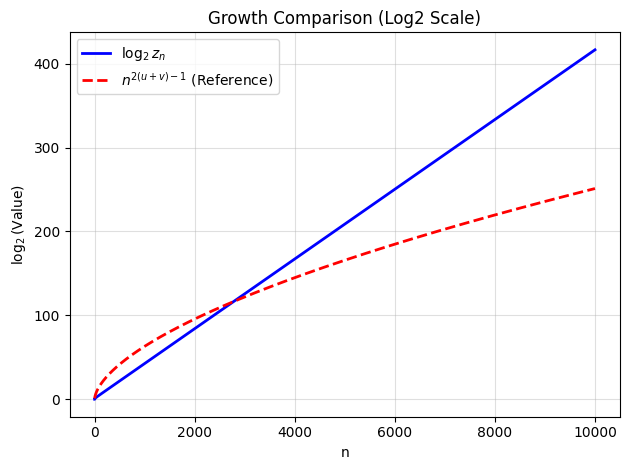

In [11]:
def compute_zns(u, v, lam, max_n):
    """
    Computes the maximum growth boundary of the extended recurrence relation 
    and compares it to the reference function lambda^(n^(2(u+v)-1)).
    """

    z = np.zeros(max_n + 1)
    z[1] = 1.0
    z[2] = 1.0
    
    constant_term = 1.0 - u - v
    
    for n in range(1, max_n - 1):
        quad_sum = sum(z[i] * z[n + 1 - i] for i in range(1, n + 1))
        linear_sum = sum(z[i] for i in range(1, n + 1))
        z[n + 2] = ((lam * u / n) * quad_sum) + ((2 * v / n) * linear_sum) + constant_term

    # drop z_0: return z1..z_max_n to avoid using the unused zero index
    return z[1:]


u = 0.5
v = 0.3
_lambda = 1.01
N = 10000

zns = compute_zns(u, v, _lambda, N)

# n corresponding to z1..zN
n = np.arange(1, len(zns) + 1)

# Safe log2: mask non-positive values to avoid warnings
log2_z = np.where(zns > 0, np.log2(zns), np.nan)

exponent_power = 2 * (u + v) - 1
log2_reference = n ** exponent_power

# Check for exponential behavior (safe division)
denom = zns[:-1]
ratios = np.where(denom == 0, np.nan, zns[1:] / denom)
n_ratios = np.arange(1, len(zns))

# Log-Log Slope: use safe logs to avoid warnings on non-positive entries
log_n = np.log(n_ratios)
log_z = np.where(zns[1:] > 0, np.log(zns[1:]), np.nan)
local_poly_degree = np.divide(np.diff(log_z), np.diff(log_n), out=np.full(np.diff(log_z).shape, np.nan), where=np.isfinite(np.diff(log_z)))
n_slopes = n_ratios[:-1]

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

plt.plot(n, log2_z, 'b-', linewidth=2, label=r'$\log_2 z_n$')
plt.plot(n, log2_reference, 'r--', linewidth=2, label=r'$n^{2(u+v)-1}$ (Reference)')
plt.xlabel('n')
plt.ylabel(r'$\log_2(\mathrm{Value})$')
plt.title('Growth Comparison (Log2 Scale)')
plt.legend()
plt.grid(True, alpha=0.4)

# # Right Plot: Consecutive Term Ratios (Checking for exponential stabilization)
# ax1_twin = ax2.twinx()
# ax2.plot(n_ratios[5:], ratios[5:], 'g-', label=r'Ratio $z_{n+1}/z_n$ (Left Axis)')
# ax1_twin.plot(n_slopes[5:], local_poly_degree[5:], 'm--', label=r'Poly Degree $\frac{\Delta \ln z_n}{\Delta \ln n}$ (Right Axis)')

# ax2.set_xlabel('n')
# ax2.set_ylabel('Ratio Value', color='g')
# ax1_twin.set_ylabel('Effective Polynomial Degree', color='m')
# ax2.set_title('Asymptotic Growth Fingerprint')

# # Combine legends for the twin axis plot
# lines, labels = ax2.get_legend_handles_labels()
# lines2, labels2 = ax1_twin.get_legend_handles_labels()
# ax2.legend(lines + lines2, labels + labels2, loc='upper left')
# ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


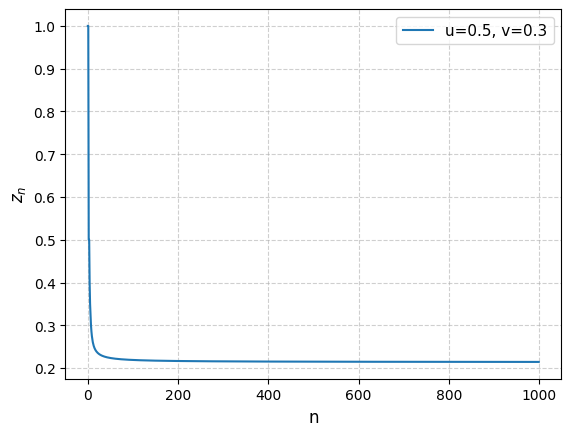

0.2143885764486614


In [7]:
def compute_zns(N, u, v):
    """
    Computes the first 'N' elements of the sequence z_n.
    Initial conditions: z_0 = 1, z_1 = 1
    """
    z = np.zeros(N)
    z[0] = 1.0
    z[1] = 1.0
    
    # Generate terms sequentially up to the requested count
    for n in range(1, N - 1):
        # Compute the convolution sum: \sum_{i=0}^{n-1} z_i * z_{n-1-i}
        convolution = sum(z[i] * z[n - 1 - i] for i in range(n))
        
        # Calculate the next term z_{n+1}
        z_next = 1.0 - u - v + (v / n) * convolution
        z[n + 1] = z_next

    return z


N = 1000

u=0.5
v=0.3


z_values = compute_zns(N, u, v)

plt.plot(range(len(z_values)), z_values, linestyle='-', label=f'u={u}, v={v}')

plt.xlabel('n', fontsize=12)
plt.ylabel('$z_n$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

print(z_values[-1])